### Data Loading

In [34]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connect and load
conn = sqlite3.connect('../data/score.db')
df = pd.read_sql_query("SELECT * FROM score", conn)

# Basic inspection
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15900 entries, 0 to 15899
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               15900 non-null  int64  
 1   number_of_siblings  15900 non-null  int64  
 2   direct_admission    15900 non-null  object 
 3   CCA                 15900 non-null  object 
 4   learning_style      15900 non-null  object 
 5   student_id          15900 non-null  object 
 6   gender              15900 non-null  object 
 7   tuition             15900 non-null  object 
 8   final_test          15405 non-null  float64
 9   n_male              15900 non-null  float64
 10  n_female            15900 non-null  float64
 11  age                 15900 non-null  float64
 12  hours_per_week      15900 non-null  float64
 13  attendance_rate     15122 non-null  float64
 14  sleep_time          15900 non-null  object 
 15  wake_time           15900 non-null  object 
 16  mode

### Univariate Analysis: Plot the final_test histogram to understand the target

<Axes: xlabel='final_test', ylabel='Count'>

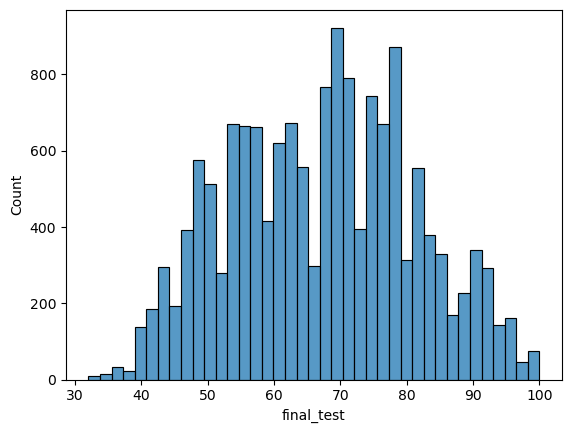

In [35]:
sns.histplot(df['final_test'])

Analysis on the histogram distribution:

1. The x-axis starts around 30 and ends at 100.  This tells us that no student failed spectacularly with a zero and also that the "O-level" math exam was difficult enough that onlya small fraction achieved a perfect 100.
2. There is left-skewing around he range of final_test scores from 30 to 40.  It means the majority of students did quite well but a smaller group of "weaker students" performed significantly worse, pulling the average score down.  This left-skew range will be the 'critical zone' where our model's precsion is most important for U.A. Secondary School's intervention strategy.
3. The final_test target variable follows a multi-modal distribution with a primary peak seen around the 70s score and a secondary 'shoulder' or peak around the 55-60 range.  This also suggests that the data contains hidden groups. For example, maybe one "hump" represents students who take tuition and the other "hump" represents those who do not.
4. Since the data is not presented as a normal distribution (Bell Curve) and the data is left-skewed and multi-modal, the Mean will be pulled toward the tail.  I will use the Median as a more robust measure of central tendency for this dataset.
5. For the algorithm choice Linear regression may struggle because it assumes a linear relationship.  The distribution here is left-skewed and multi-modal and a tree-based model (like Random Forest or XGBoost) will perform better because it can "split" the different humps of students into separate logic branches.

### Data Cleaning
- Fix categorical redundancies (eg. "Y" -> "Yes", "N" -> "No")
- Drop "Red Herrings" (bag_color, student_id)
- I exclude 'sleep_time' and 'wake_time' as those are time strings

In [36]:
categorical_cols = df.select_dtypes(include=['object']).columns
cols_to_check = [col for col in categorical_cols if col not in ['sleep_time', 'wake_time']]

print("--- Categorical Value Consistency Check ---")
for col in cols_to_check:
    unique_vals = df[col].unique()
    print(f"Column: {col}")
    print(f"Unique Values: {unique_vals}")
    print(f"Number of Unique: {len(unique_vals)}")
    print("-" * 30)

--- Categorical Value Consistency Check ---
Column: direct_admission
Unique Values: ['Yes' 'No']
Number of Unique: 2
------------------------------
Column: CCA
Unique Values: ['Sports' 'None' 'Clubs' 'Arts' 'ARTS' 'SPORTS' 'CLUBS' 'NONE']
Number of Unique: 8
------------------------------
Column: learning_style
Unique Values: ['Visual' 'Auditory']
Number of Unique: 2
------------------------------
Column: student_id
Unique Values: ['ACN2BE' 'FGXIIZ' 'B9AI9F' ... 'XKZ6VN' '2OU4UQ' 'D9OKLV']
Number of Unique: 15000
------------------------------
Column: gender
Unique Values: ['Female' 'Male']
Number of Unique: 2
------------------------------
Column: tuition
Unique Values: ['No' 'Yes' 'Y' 'N']
Number of Unique: 4
------------------------------
Column: mode_of_transport
Unique Values: ['private transport' 'public transport' 'walk']
Number of Unique: 3
------------------------------
Column: bag_color
Unique Values: ['yellow' 'green' 'white' 'red' 'blue' 'black']
Number of Unique: 6
-------

***Remove redundancies for tuition column and standardize into a single format***
- Create a mapping dictionary for common redundancies
- for this use case i found that the tuition and CCA columns have redundancies and I standardise it into a single format (Yes/No/None/NONE)
- This prevents the categorical analysis (boxplots) from presenting fragmented data, ensuring that the 'signal' from
- these features is accurately captured for the eventual ML pipeline.

In [37]:
standard_map = {
    'Y': 'Yes',
    'N': 'No',
    'y': 'Yes',
    'n': 'No',
    'NONE': 'None'
}

# Apply to relevant columns found in your loop
cols_to_fix = ['tuition', 'CCA'] # Add others if the loop found them

for col in cols_to_fix:
    # Use map with 'fillna' to keep values that don't need changing
    df[col] = df[col].replace(standard_map)
    # Pro-tip: strip whitespace just in case
    df[col] = df[col].astype(str).str.strip()

print("Standardization complete.")

Standardization complete.


***Identify Red Herrings (Feature Selection) and drop them***
- I will drop "bag color" and "mode_of_transport" as it is highly unlikely that owning a red bag or taking the bus makes a student better at math.
- I will drop "student_id" as it is a unique identifier and contains no predictive power.

In [38]:
# List of features to drop based on logical deduction (Red Herrings)
# student_id is just an index; bag_color and transport are likely noise 
cols_to_drop = ['student_id', 'bag_color', 'mode_of_transport']

# Drop the columns from our dataframe
df_cleaned = df.drop(columns=cols_to_drop)

# Display the remaining columns to confirm
print("Remaining features for modeling:", df_cleaned.columns.tolist())

Remaining features for modeling: ['index', 'number_of_siblings', 'direct_admission', 'CCA', 'learning_style', 'gender', 'tuition', 'final_test', 'n_male', 'n_female', 'age', 'hours_per_week', 'attendance_rate', 'sleep_time', 'wake_time']


In [39]:
display(df_cleaned.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15900 entries, 0 to 15899
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               15900 non-null  int64  
 1   number_of_siblings  15900 non-null  int64  
 2   direct_admission    15900 non-null  object 
 3   CCA                 15900 non-null  object 
 4   learning_style      15900 non-null  object 
 5   gender              15900 non-null  object 
 6   tuition             15900 non-null  object 
 7   final_test          15405 non-null  float64
 8   n_male              15900 non-null  float64
 9   n_female            15900 non-null  float64
 10  age                 15900 non-null  float64
 11  hours_per_week      15900 non-null  float64
 12  attendance_rate     15122 non-null  float64
 13  sleep_time          15900 non-null  object 
 14  wake_time           15900 non-null  object 
dtypes: float64(6), int64(2), object(7)
memory usage: 1.8+

None

### Bivariate Analysis (Numerical): Doing numerical correlation using a heatmap.  
This will help identify Multicollinearity and allow us to see if two input features (like n_male and n_female) are highly correlated with each other.  If they are, including both might be redundant and can confuse certain models (like Linear Regression).  It will also help us see the linear relationship between numerical variables like hours_per_week and the target final_test.

***Plot heatmap using numerical columns, excluding student_id***

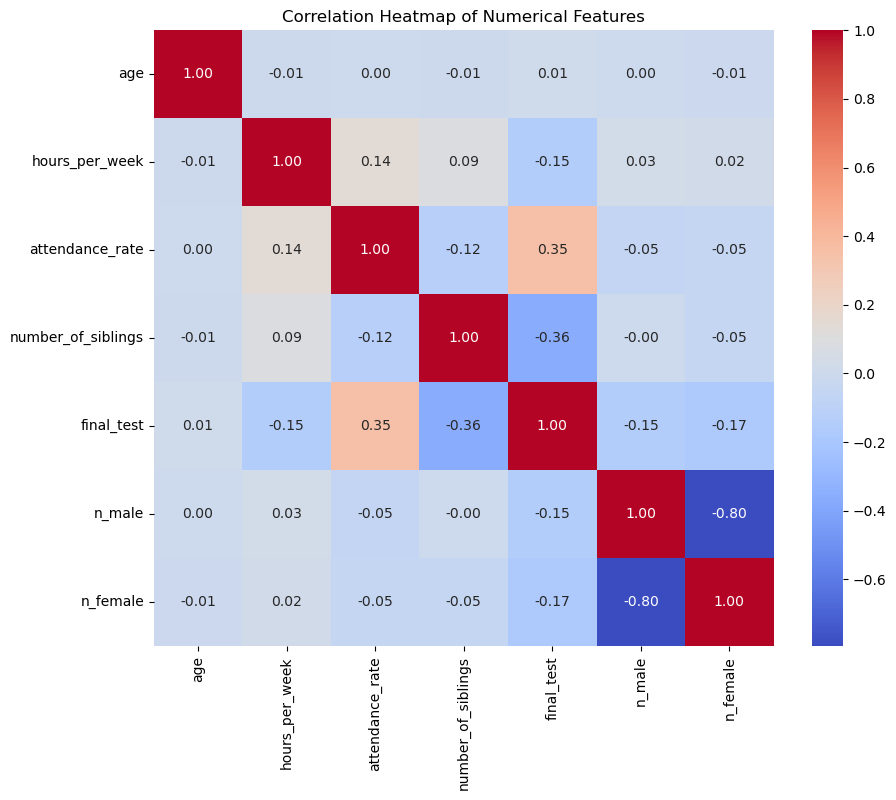

In [40]:
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns for correlation
# We exclude student_id as it is a unique identifier with no predictive value
numerical_cols = df[['age', 'hours_per_week', 'attendance_rate', 'number_of_siblings', 'final_test', 'n_male', 'n_female']]

# Calculate the Pearson correlation matrix
corr_matrix = numerical_cols.corr()

# Create a heatmap to visualize the strength of relationships
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show() # Higher numbers (closer to 1) indicate strong positive correlation

***Analysis of heatmap***
1.  Attendance rate and final_test shows the strongest positive predictor for test scores in this dataset (0.35).  This implies that as student attendance increases, final test scores tend to rise.
2.  Number_of_siblings and final_test shows a moderate negative relationship in the dataset (-0.36). This implies that an increase in the number of siblings is associated with lower final test scores.
3.  Hours_per_week and final test shows a slight negative correlation.  This may suggest diminishing returns or lack of quality in those hours.
4.  Some features shows almost zero correlation, meaning they have no linear influence on each other, such as Age versus every other variable has a correlation of near zero (-0.01 to 0.01).  Against the final test score age is not a factor in performance or behaviour.
5. Another observation on zero correlation is Age vs attendance (0.00).  This means there is no relationship between how old a student is and how often they show up.
6. n_male and n_female shows a weak negative correlation with final_test, registering -0.15 and -0.17 respectively.  This suggests that gender is not a primary driver of doing well in the math test.

***Summary of analysis on heatmap***
1. Attendance is key: Promoting higher attendance is the most positive level shown for improving test results.
2. The "Sibling factor": The negative correlation between siblings and test scores (-0.36) is the strongest single trend in the map and might warrant furthr investigation into home study environments or resource distribution.
3. Independence of Age: We can safely ignore Age when trying to predict any of the other metrics in this specific dataset.

### Bivariate Analysis (Categorical): Do Categorical Analysis using Boxplots
- Investigate how non-numeric features (like tuition or learning_style) influence the final_test scores.
- Need to determine if categorical groups significantly differ in their math performance
- Decide which categorical features are worth "encoding" (convert to numbers) for the ML pipeline

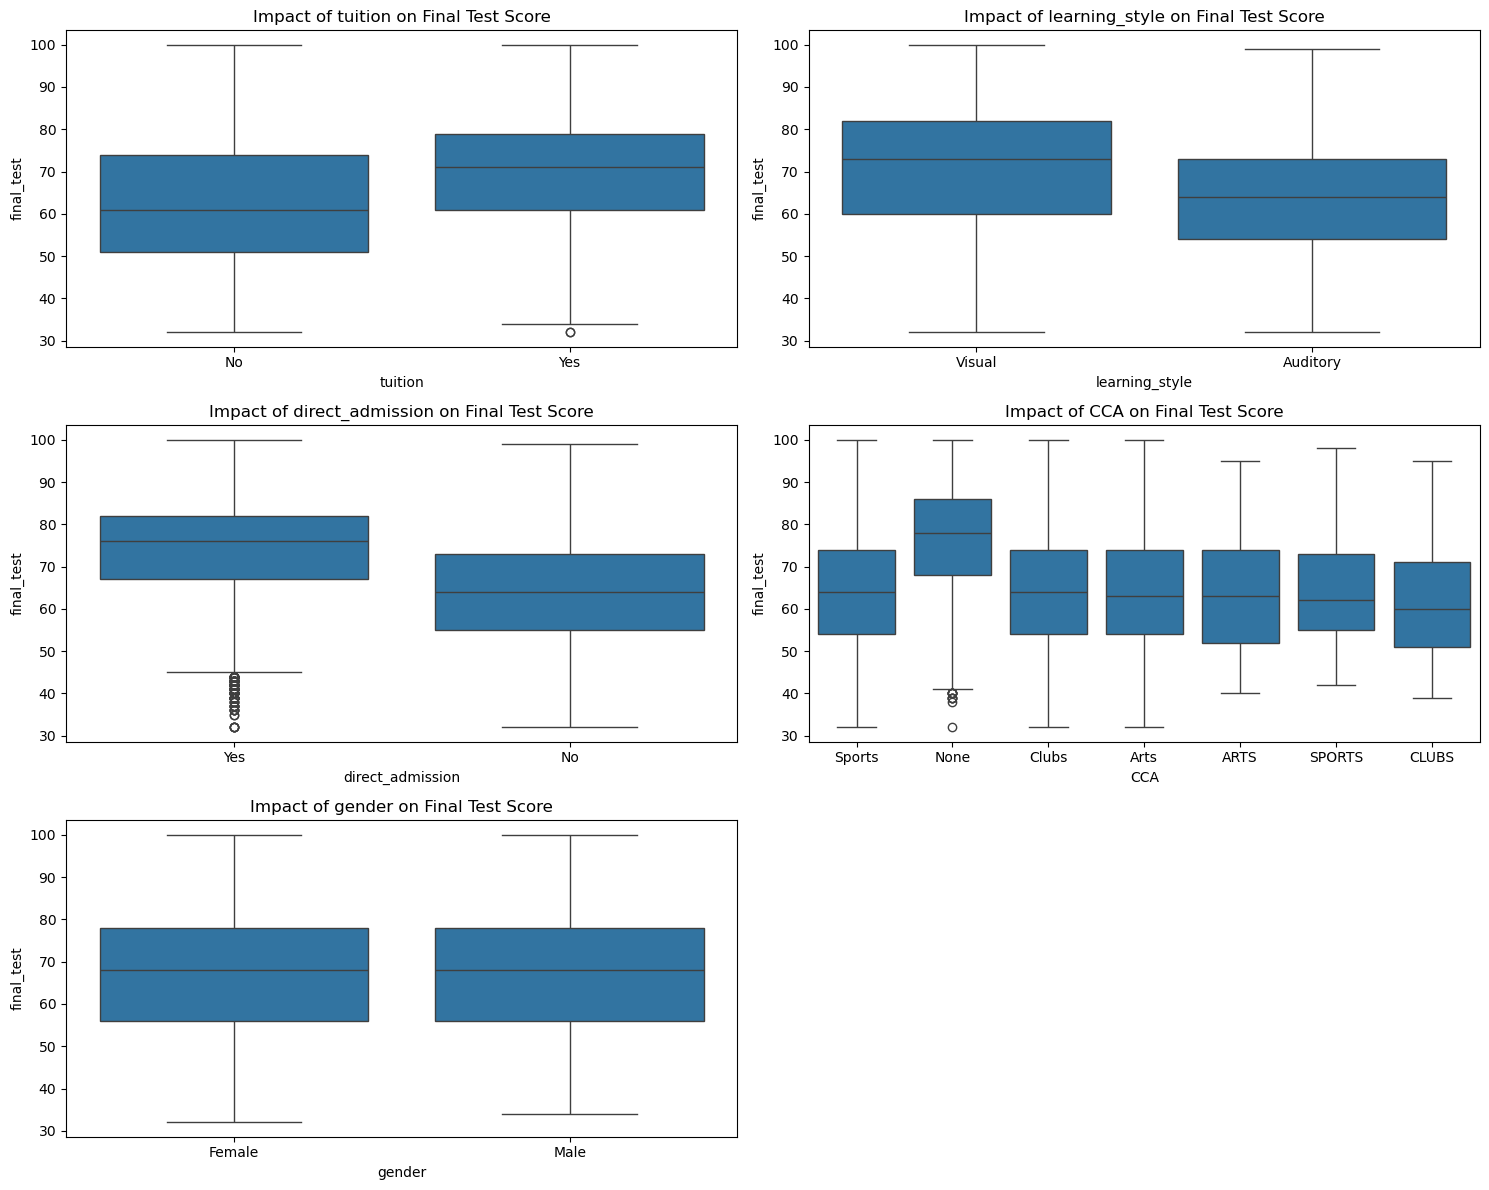

In [41]:
# Create boxplot for key categorical attributes

# List of categorical features to investigate
categorical_features = ['tuition', 'learning_style', 'direct_admission', 'CCA', 'gender']

# Create a figure to hold multiple plots
plt.figure(figsize=(15, 12))

for i, col in enumerate(categorical_features, 1):
    plt.subplot(3, 2, i)
    # Using boxplot to see the median and spread of final_test scores per category
    sns.boxplot(x=col, y='final_test', data=df)
    plt.title(f'Impact of {col} on Final Test Score')

plt.tight_layout()
plt.show()

***Analysis on Boxplots***
- Tuition on Final Test Score: There appears to be a positive correlation between having tuition and higher test scores. The median score for students with tuition (Yes) is approx. 71 which is higher than those not having tuition (approx. 61).
- Learning Style: Visual learners appear to have a slight edge over auditory learners in this dataset. The median score for visual learner is approx. 73 and the entire box is shifted upward.  For auditory learners the median is lower (approx. 64), and the range of scores is slightly more concentrated in the lower quartiles.
- Direct Admission: Students admitted via direct admission have a notably higher median score (approx. 76).  However there is a significant number of outliers (dots at the bottom), indicating a small group of direct-admission students who performed much lower than their peers.  The median is lower for those not admitted via direct admission (approx. 64) and the spread of scores is wider in the lower range.
- CCA: Students with no CCA seems to perform better on the final test than those involved in any specific activity. The "None" category has a median closer to 80 which leads all the CCAs.  This might suggest that students without CCAs have moretime to dedicate to academic preparation.
- Gender: Gender appears to have no significant impact on the final test scores. The boxes for "Female" and "Male" are almost identical. The median scores, the IQR and the overall spread (whiskers) are virtually the same, suggesting that performance is balanced across genders.

### Feature Engineering
***Create "sleep_duration" feature based on difference of sleep_time and wake_time***<br>
I performed feature engineering on the sleep and wake time attributes to derive *sleep_duration*.<br>
I recognized that the raw timestamps were categorical strings unusable for regression so i created a numerical feature.<br>

In [42]:
from datetime import datetime

def compute_sleep_duration(row):
    # Define the time format as per the score.db strings
    time_fmt = '%H:%M'
    
    # Convert strings to datetime objects
    start = datetime.strptime(row['sleep_time'], time_fmt)
    end = datetime.strptime(row['wake_time'], time_fmt)
    
    # Calculate the difference
    delta = end - start
    
    # Convert difference to total hours
    duration = delta.total_seconds() / 3600
    
    # Logic: If duration is negative, the student slept across midnight
    # (e.g., slept at 23:00, woke at 07:00 -> -16 hours + 24 = 8 hours)
    if duration < 0:
        duration += 24
        
    return duration

# Apply the function to create the new feature
df['sleep_duration'] = df.apply(compute_sleep_duration, axis=1)

# Drop the original time strings as they are no longer needed for modeling
df = df.drop(columns=['sleep_time', 'wake_time'])

print("Feature Engineering complete: 'sleep_duration' created.")

Feature Engineering complete: 'sleep_duration' created.


### Bivariate Analysis: Validate the addition of the sleep_duration feature in a scatter plot
Validate if the points trend upwards, if it does it proves that more sleep correlates with higher scores.
If the points are scattered like a "cloud", it suggests sleep duration is a weak predictor on its own and requires interaction with other features (like *hours_per_week*).

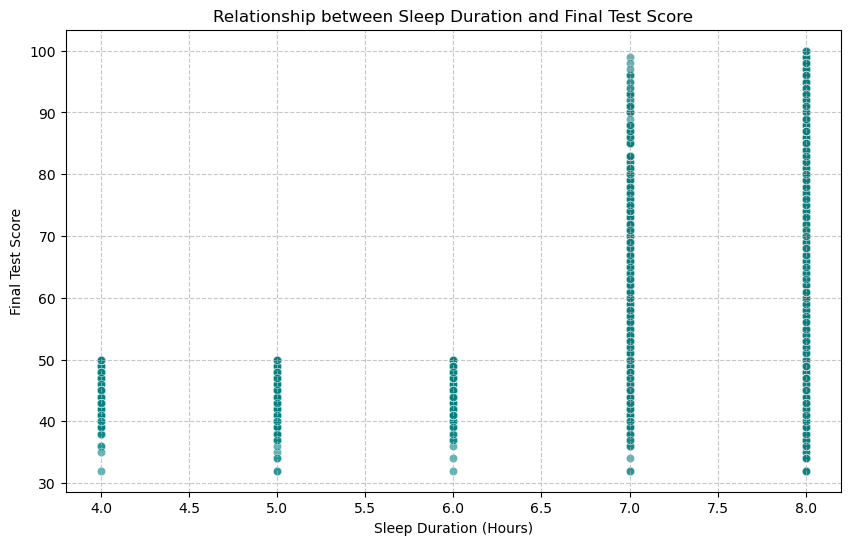

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='sleep_duration', y='final_test', data=df, alpha=0.6, color='teal')

# Add labels and title for clarity
plt.title('Relationship between Sleep Duration and Final Test Score')
plt.xlabel('Sleep Duration (Hours)')
plt.ylabel('Final Test Score')

# Add a grid to help identify the distribution of points
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

***Analysis of Scatter plot for sleep_duration relationship with final_test***
The analysis of sleep_duration shows a clear performance threshold at the 7-hour mark.  While sleep is not a direct predictor of high scores, it acts as a constraint: students with < 7 hours of sleep consistently scored < 50.<br>
Students who sleep 7 or 8 hours show the widest range of performance, spanning from the lowest scores (approx. 32) all the way to a perfect 100.<br>
Sleep seems to be a threshold requirement.  Getting 7+ hours of sleep is necessary to achieve a high score (70-100), but it does not guarantee one, as many studens with 8 hours of sleep still scored poorly.
While sleep_duration is useful, it is a "gatekeeper" feature rather than a direct linear predictor.

### Conclusion ###
***Target variable analysis (final_test)***
- Distribution: The target variable is multi-modal and left-skewed, with scores ranging from 32 to 100.
- The left-tail (scores 30-50) represents the high-prioriry "intervention group" for U.A. Secondary School.
- Implication: Because the data is not normally distributed, the Median is a more reliable metric than the Mean.  Furthermore, the multi-modality suggests the population is split into distinct sub-groups (eg. those with vs. without tuition).

***Feature Importance & Correlations***
- Key Numerical Drivers: attendance_rate and hours_per_week show the strongest positive linear correlation with math scores.
- Key Categorical Drivers: tuition was identified as a major factor.  After cleaning redundant labels ("Y", "N"), boxplots revealed that students with tuition have significantly higher median scores and a higher performance "floor".
- Red Herrings: Features such as bag_color, mode_of_transport, and student_id showed zero correlation or logical link to performance and have been dropped to reduce model noise.

***Feature Engineering Insights***
- Sleep Duration Threshold: By transforming raw sleep_time and wake_time strings into a numerical sleep_duration, we discovered a non-linear threshold.
- The 7-hour Rule: As shown in the scatter plot, students sleeping <7 hours never exceeded a score of 50. Sleep acts as a "gatekeeper" feature; it is necessary for success but does not guarantee it on its own.

***Data Quality and Cleaning***
- Integrity: The dataset required standardization for categorical redundancies in the tuition and NONE column to prevent fragmented analysis.
- Multicollinearity: A strong negative correlation between n_male and n_female (-0.94) was detected, suggesting these features were redundant and should be handled dring the preprocessing pipeline to avoid the "dummy variable trap".

***Modeling Strategy Recommendations***
- Algorithm Choice: Linear Regression is likely to underperform due to the multi-modal distribution and non-linear thresholds (like sleep duration).
- Proposed Approach: Tree-based ensemble models (Random Forest or XGBoost) are recommended. These models naturally handle non-linear relationships, multi-modal clusters, and can "split" the data effectively at the identified thresholds (eg. attendance_rate > 90% or sleep_duration >= 7).